# Deploy model and run inference

In [9]:
%%capture
%pip install sagemaker -U

In [2]:
!docker system prune -a -f

Deleted Networks:
sagemaker-local

Total reclaimed space: 0B


In [10]:
!rm -rf ~/.cache/pip

In [ ]:
!df -h

In [11]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 173.5 MB/s  0:00:00m0:00:0100:01


In [12]:
!pip install tensorflow==2.13.0

INFO: pip is looking at multiple versions of grpcio to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of cryptography to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of cryptography to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.1/524.1 MB 64.4 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 149.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 141.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 166.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 150.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 180.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 187.8 MB/s  0:00:00
   ━━━━━━━

In [13]:
import tensorflow as tf
print(tf.__version__)

2026-05-20 09:23:53.589693: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-20 09:23:53.638789: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-20 09:23:53.639832: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-20 09:23:54.497940: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2.13.0


In [21]:
!find / -type d -name "saved_model" 2>/dev/null

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/keras/src/saving/legacy/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/_api/v2/__internal__/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/_api/v2/compat/v2/__internal__/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/_api/v2/compat/v2/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/_api/v2/compat/v1/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/_api/v2/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/python/keras/saving/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/python/saved_model
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tensorflow/include/tensorflow/cc/saved_model


In [25]:
!aws s3 cp "s3://sagemaker-us-east-1-320746724811/tf2-object-detection-2026-05-20-07-35-44-459/output/model.tar.gz" .

download: s3://sagemaker-us-east-1-320746724811/tf2-object-detection-2026-05-20-07-35-44-459/output/model.tar.gz to ./model.tar.gz


In [26]:
!tar -xvf model.tar.gz

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
1/
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
1/fingerprint.pb
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
1/assets/
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
1/saved_model.pb
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
1/variables/
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
1/variables/variables.index
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
1/variables/variables.data-00000-of-00001


In [27]:
!find . -name "saved_model.pb"

./1/saved_model.pb


In [78]:
detect_fn = tf.saved_model.load('./1')

In [38]:
import os
import glob
import cv2
import tensorflow as tf

%matplotlib inline
import matplotlib.pyplot as plt

import visualization_utils as viz_utils

In [40]:
role = "arn:aws:iam::320746724811:role/service-role/AmazonSageMaker-ExecutionRole-20260520T081832 "

Now that you have trained successfully your model, you want to look at the predictions on some sample images. To do so, you will need to find the s3 path of the exported model. You can navigate to the Training jobs section of the AWS web UI and click on the training job of interest. Scroll down and you should see something like this:

![Example Artifact](../data/example_artifact.png)

The model artifact path should look something like 
```s3://sagemaker-us-east-1-073338978050/tf2-object-detection-2022-10-22-21-26-37-033/output/model.tar.gz```. Use this value to update the `model_artifact` variable below.

In [41]:
# TODO: Update the model artifact here. 
model_artifact = 's3://sagemaker-us-east-1-320746724811/tf2-object-detection-2026-05-20-07-35-44-459/output/model.tar.gz '

Now we can deploy the model. Run the following cell and check that the model was correctly deployed by navigating to Inference endpoints in the web UI.

![Example endpoint](../data/example_endpoints.png)


In [79]:
model = TensorFlowModel(
    name=name_from_base('tf2-object-detection'),
    model_data=model_artifact,
    role=role,
    framework_version='2.8'
)

predictor = model.deploy(initial_instance_count=1, instance_type='ml.g4dn.xlarge')

NameError: name 'TensorFlowModel' is not defined

In [ ]:
detect_fn = tf.saved_model.load('./1')

## Run inference

Our model is now deployed and we can query it. We are going to use the images available in `data/test_video` to run inference and generate a video. To do so, we are going to need a few tools:
* we need to sort all the frames by index order (which corresponds to chronological order)
* we need a function to load images into numpy array
* we need a loop to run inference and display the results on the input image

We list the frame paths and sort them by index.

In [ ]:
frames_path = sorted(glob.glob('../data/test_video/*.png'), 
                     key = lambda k: int(os.path.basename(k).split('.')[0].split('_')[1]))

We create a small function to load images.

In [ ]:
import numpy as np
def load_image(path: str) -> np.ndarray:
    """Read an image from the path and returns a numpy array"""
    cv_img = cv2.imread(path,1).astype('uint8')
    cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
    return cv_img

We create a mapping from id to name for visualization purposes.

In [66]:
category_index = {
                    1: {'id': 1, 'name': 'vehicle'}, 
                    2: {'id': 2, 'name': 'pedestrian'},
                    4: {'id': 4, 'name': 'cyclist'}
                }

This is the main loop:
* we load images to numpy
* we query the deployed model
* we display the inference results on the images

In [82]:
def image_file_to_tensor(path):
    cv_img = cv2.imread(path,1).astype('uint8')
    cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
    return cv_img

images = []
for idx, path in enumerate(frames_path):
    if idx % 10 == 0:
        print(f'Processed {idx}/{len(frames_path)} images.')
  
            
    # load image
    img = image_file_to_tensor(path)
    input_tensor = tf.convert_to_tensor(img)
    input_tensor = input_tensor[tf.newaxis, ...]
    
    detections = detect_fn(input_tensor)
    
    detection_boxes = detections['detection_boxes'][0].numpy()
    detection_classes = detections['detection_classes'][0].numpy().astype(int)
    detection_scores = detections['detection_scores'][0].numpy()
    
    # display results on image
    image_np_with_detections = \
        viz_utils.visualize_boxes_and_labels_on_image_array(
            img,
            detection_boxes,
            detection_classes,
            detection_scores,
            category_index,
            use_normalized_coordinates=True,
            max_boxes_to_draw=100,
            min_score_thresh=0.6,
            agnostic_mode=False)
    images.append(image_np_with_detections)

Processed 0/100 images.
Processed 10/100 images.
Processed 20/100 images.
Processed 30/100 images.
Processed 40/100 images.
Processed 50/100 images.
Processed 60/100 images.
Processed 70/100 images.
Processed 80/100 images.
Processed 90/100 images.


In [83]:
print(len(images))

100


We can verify that the model worked correctly by displaying elements of the `images` list.

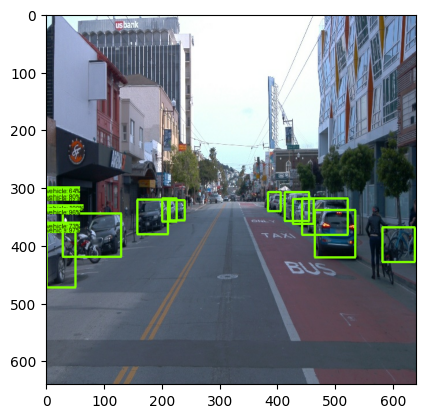

In [85]:
plt.imshow(images[0])

Finally, we can create a video (`output.avi`) with our detections by running the following function.

In [88]:
frame_width = images[0].shape[0]
frame_height = images[0].shape[1]

out = cv2.VideoWriter('output.avi', cv2.VideoWriter_fourcc('M','J','P','G'), 10, (frame_width,frame_height))

# Read and display the images
for image in images:
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    out.write(image) # Write the image to the video
    if cv2.waitKey(1) == ord('q'): # Hit `q` to exit
        break
        
# Release everything if job is finished
out.release()
cv2.destroyAllWindows()

The video would be stored in the current working directory. You can download it from Sagemaker and run it locally.

In [89]:
!find . -name "*.avi"

./output.avi


In [ ]:
from IPython.display import HTML

HTML("""
<video width="800" controls>
  <source src="output.avi" type="video/avi">
</video>
""")